In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# 0. CARGA Y PREPARACIÓN DE DATOS

# Cargar el dataset
id_archivo = '1jhgverpcRuw_KubIZZ1dZK4D8cgioMOd'
url = f'https://drive.google.com/uc?id={id_archivo}'
df = pd.read_csv(url)

# Eliminar variables identificadoras que no aportan valor predictivo
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

In [2]:
!pip freeze | grep -iE "pandas|numpy|scikit-learn|imbalanced-learn|scipy"

geopandas==1.1.4
imbalanced-learn==0.14.2
numpy==2.1.3
pandas==2.2.3
pandas-datareader==0.11.1
pandas-gbq==0.30.0
pandas-stubs==2.2.3.250527
scikit-learn==1.6.1
scipy==1.16.3
sklearn-pandas==2.2.0


1. RESUMEN ESTADÍSTICO (Numéricas)



In [3]:
# 1. RESUMEN ESTADÍSTICO (Numéricas)
print("--- 1. RESUMEN ESTADÍSTICO ---")
num_vars = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
# Incluimos percentiles específicos
stats = df_clean[num_vars].describe(percentiles=[.25, .50, .75]).T
print(stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])

--- 1. RESUMEN ESTADÍSTICO ---
                          mean           std     min       25%         50%  \
CreditScore         650.528800     96.653299  350.00    584.00     652.000   
Age                  38.921800     10.487806   18.00     32.00      37.000   
Tenure                5.012800      2.892174    0.00      3.00       5.000   
Balance           76485.889288  62397.405202    0.00      0.00   97198.540   
NumOfProducts         1.530200      0.581654    1.00      1.00       1.000   
EstimatedSalary  100090.239881  57510.492818   11.58  51002.11  100193.915   

                         75%        max  
CreditScore         718.0000     850.00  
Age                  44.0000      92.00  
Tenure                7.0000      10.00  
Balance          127644.2400  250898.09  
NumOfProducts         2.0000       4.00  
EstimatedSalary  149388.2475  199992.48  



2. DETECCIÓN DE ANOMALÍAS (Boxplots)



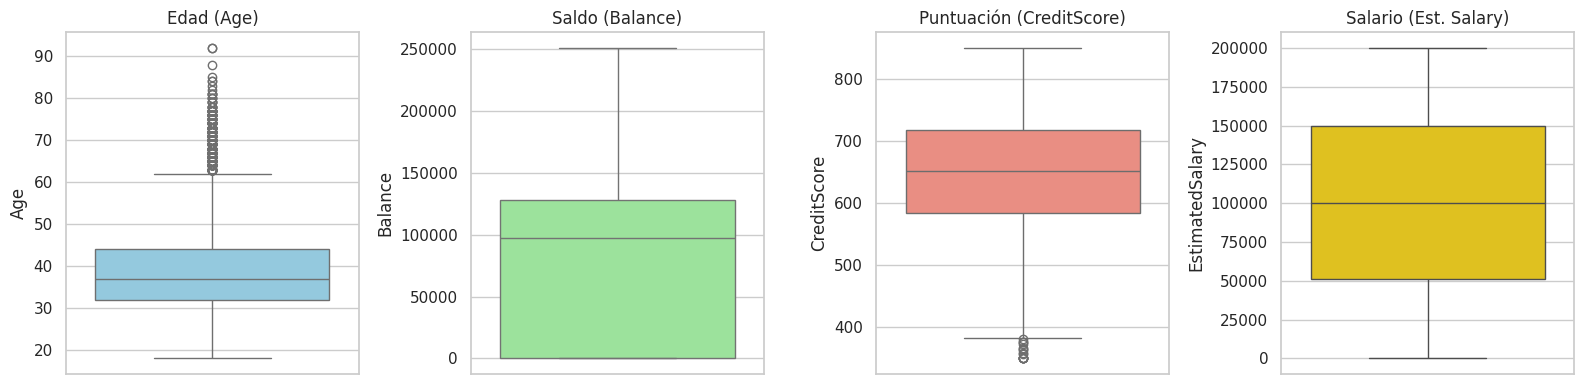

In [4]:
# 2. DETECCIÓN DE ANOMALÍAS (Boxplots)
# Crear una figura con 4 subgráficos horizontales
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sns.boxplot(y=df_clean['Age'], ax=axes[0], color='skyblue').set_title('Edad (Age)')
sns.boxplot(y=df_clean['Balance'], ax=axes[1], color='lightgreen').set_title('Saldo (Balance)')
sns.boxplot(y=df_clean['CreditScore'], ax=axes[2], color='salmon').set_title('Puntuación (CreditScore)')
sns.boxplot(y=df_clean['EstimatedSalary'], ax=axes[3], color='gold').set_title('Salario (Est. Salary)')

plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=300)
plt.show()


3. COMPROBACIÓN DE SUPUESTOS (Histogramas)

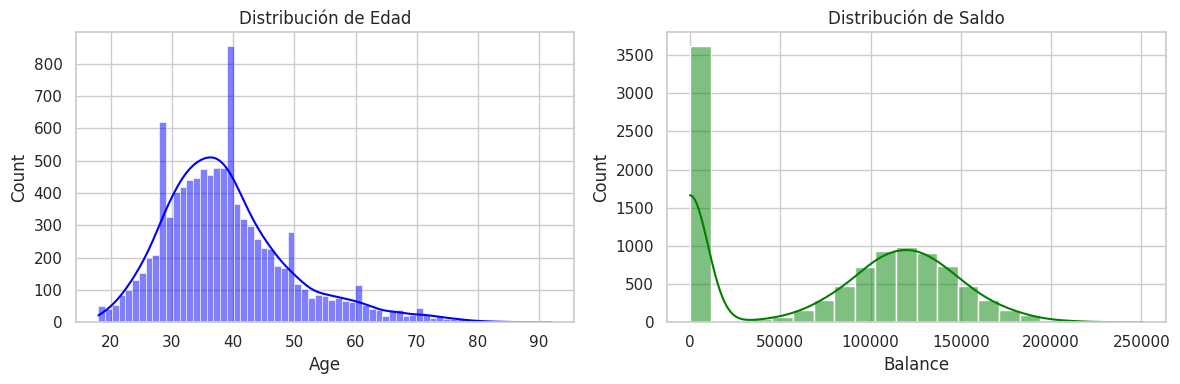

In [5]:
 # 3. COMPROBACIÓN DE SUPUESTOS (Histogramas)

# Evaluar la normalidad y distribuciones bimodales
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_clean['Age'], kde=True, ax=axes[0], color='blue').set_title('Distribución de Edad')
sns.histplot(df_clean['Balance'], kde=True, ax=axes[1], color='green').set_title('Distribución de Saldo')

plt.tight_layout()
plt.savefig('histograms_dist.png', dpi=300)
plt.show()

4. PATRONES Y RELACIONES (Scatter Plot & Correlación)

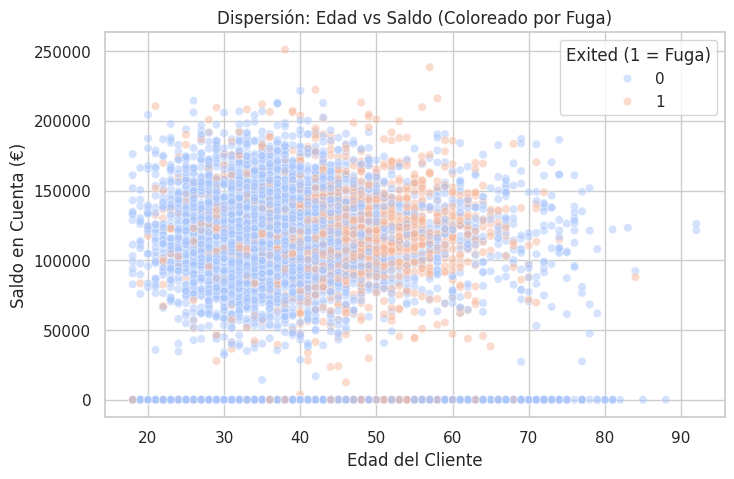

In [6]:
# 4. PATRONES Y RELACIONES (Scatter Plot & Correlación)
# A. Diagrama de Dispersión (Edad vs Saldo)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='Age', y='Balance', hue='Exited', alpha=0.5, palette='coolwarm')
plt.title('Dispersión: Edad vs Saldo (Coloreado por Fuga)')
plt.xlabel('Edad del Cliente')
plt.ylabel('Saldo en Cuenta (€)')
plt.legend(title='Exited (1 = Fuga)', loc='upper right')
plt.savefig('scatter_age_balance.png', dpi=300)
plt.show()


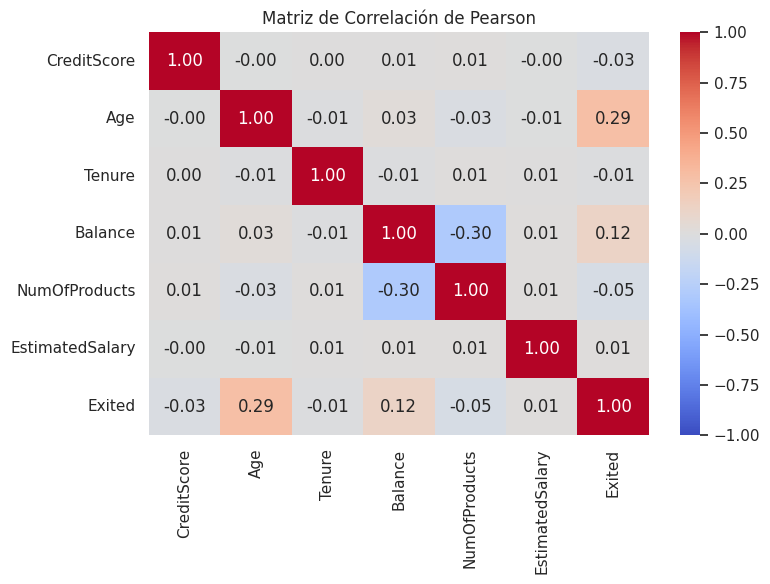

In [7]:

# B. Matriz de Correlación de Pearson
plt.figure(figsize=(8, 6))
corr_matrix = df_clean[num_vars + ['Exited']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Pearson")
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=300)
plt.show()

5. PRUEBAS CHI-CUADRADO (Categóricas vs Target)

In [8]:
print("\n--- 5. PRUEBAS DE SIGNIFICANCIA (Chi-Cuadrado) ---")
cat_vars = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

for cat in cat_vars:
    contingency = pd.crosstab(df_clean[cat], df_clean['Exited'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"Variable '{cat}' vs Exited: p-value = {p:.4e}")
    if p < 0.05:
        print("   -> Estadísticamente significativa (Dependiente)")
    else:
        print("   -> NO significativa (Independiente)")


--- 5. PRUEBAS DE SIGNIFICANCIA (Chi-Cuadrado) ---
Variable 'Geography' vs Exited: p-value = 3.8303e-66
   -> Estadísticamente significativa (Dependiente)
Variable 'Gender' vs Exited: p-value = 2.2482e-26
   -> Estadísticamente significativa (Dependiente)
Variable 'HasCrCard' vs Exited: p-value = 4.9237e-01
   -> NO significativa (Independiente)
Variable 'IsActiveMember' vs Exited: p-value = 8.7859e-55
   -> Estadísticamente significativa (Dependiente)
